## Import all the required libraries

In [1]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions   # plot decision boundary

## Creating manual dataset

In [2]:
df = pd.DataFrame()

In [3]:
df['Feature1'] = [1,2,3,4,5,6,7,8,9,9]
df['Feature2'] = [5,3,6,8,1,9,5,8,9,2]
df['target'] = [1,1,0,1,0,1,0,1,0,0]

In [4]:
df

,Feature1,Feature2,target
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,7,5,0
7,8,8,1
8,9,9,0
9,9,2,0


In [5]:
df.shape

(10, 3)

In [6]:
print(df.head())

   Feature1  Feature2  target
0         1         5       1
1         2         3       1
2         3         6       0
3         4         8       1
4         5         1       0


## Relationship between the features in a given dataframe

<Axes: xlabel='Feature1', ylabel='Feature2'>

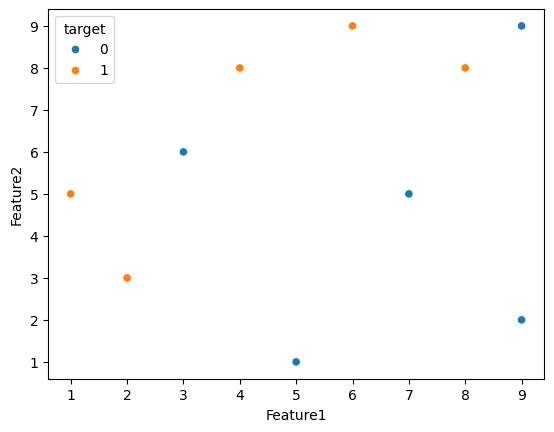

In [7]:
import seaborn as sns
sns.scatterplot(x=df['Feature1'],y=df['Feature2'],hue=df['target'])
# hue classifies data on the basis of hue gives labelling


## Weight initialization

Weight initialization in the first iteration: 1 / num_records


1/10 = 0.1 (Weight initialization of all the 10 records in a given dataframe)

In [8]:
df['weights'] = 1/df.shape[0]

In [9]:
df

,Feature1,Feature2,target,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,7,5,0,0.1
7,8,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [10]:
from sklearn.tree import DecisionTreeClassifier
dt1 = DecisionTreeClassifier(max_depth=1)


Split the data into input features and target label

In [12]:
df.columns

Index(['Feature1', 'Feature2', 'target', 'weights'], dtype='object')

In [11]:
## X - input Features
## y - target label

X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [13]:
X

array([[1, 5],
       [2, 3],
       [3, 6],
       [4, 8],
       [5, 1],
       [6, 9],
       [7, 5],
       [8, 8],
       [9, 9],
       [9, 2]])

In [14]:
y

array([1, 1, 0, 1, 0, 1, 0, 1, 0, 0])

## Model Training : M1

In [15]:
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

In [16]:
df['y_pred'] = dt1.predict(X)

In [17]:
df

,Feature1,Feature2,target,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,7,5,0,0.1,0
7,8,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [18]:
## evaluate the value of alpha
def calculate_model_weight(error):
  return 0.5*np.log((1-error)/(error))

In [21]:
# step 3 - Calculate model weight
 # 3 misclassified points: error = 0.1*3 = 0.3

alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [22]:
## Step 4 - update the weights of correctly classified points and misclassified points
def update_row_weights(row,alpha=0.423):
  ## Correctly classified points
  if row['target'] == row['y_pred']:
    return row['weights']*np.exp(-alpha)
  ## Misclassified points
  else:
    return row['weights']*np.exp(alpha)


In [24]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)
df

,Feature1,Feature2,target,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,0,0.152653
6,7,5,0,0.1,0,0.065508
7,8,8,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
9,9,2,0,0.1,0,0.065508


In [27]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [28]:
df['normalized_weights'] = df['updated_weights']/df['updated_weights'].sum()
df

,Feature1,Feature2,target,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,0,0.065508,0.071475
3,4,8,1,0.1,0,0.152653,0.166559
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,0,0.152653,0.166559
6,7,5,0,0.1,0,0.065508,0.071475
7,8,8,1,0.1,0,0.152653,0.166559
8,9,9,0,0.1,0,0.065508,0.071475
9,9,2,0,0.1,0,0.065508,0.071475


In [31]:
# normalized weights so that the total sum become 1
df['normalized_weights'].sum()

np.float64(1.0)

In [32]:
# lower and upper boundof normalized weight
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])

In [33]:
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']

In [34]:
df[['Feature1','Feature2','target','weights','y_pred','updated_weights','normalized_weights','cumsum_lower']]

,Feature1,Feature2,target,weights,y_pred,updated_weights,normalized_weights,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.071475
2,3,6,0,0.1,0,0.065508,0.071475,0.142950
3,4,8,1,0.1,0,0.152653,0.166559,0.214425
4,5,1,0,0.1,0,0.065508,0.071475,0.380983
5,6,9,1,0.1,0,0.152653,0.166559,0.452458
6,7,5,0,0.1,0,0.065508,0.071475,0.619017
7,8,8,1,0.1,0,0.152653,0.166559,0.690492
8,9,9,0,0.1,0,0.065508,0.071475,0.857050
9,9,2,0,0.1,0,0.065508,0.071475,0.928525


## Iteration 2 : Create a new training set

In [50]:
def create_new_dataset(df):
  indices = []
  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [51]:
# upsampling (## misclassified points indices: [2,6,8])
index_Values = create_new_dataset(df)
index_Values

[1, 5, 0, 9, 7, 6, 7, 5, 8, 3]

In [53]:
second_df = df.iloc[index_Values,[0,1,2,3]]
second_df

,Feature1,Feature2,target,weights
1,2,3,1,0.1
5,6,9,1,0.1
0,1,5,1,0.1
9,9,2,0,0.1
7,8,8,1,0.1
6,7,5,0,0.1
7,8,8,1,0.1
5,6,9,1,0.1
8,9,9,0,0.1
3,4,8,1,0.1


In [54]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [55]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [56]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

In [57]:
second_df['y_pred'] = dt2.predict(X)
second_df

,Feature1,Feature2,target,weights,y_pred
1,2,3,1,0.1,1
5,6,9,1,0.1,1
0,1,5,1,0.1,1
9,9,2,0,0.1,0
7,8,8,1,0.1,1
6,7,5,0,0.1,1
7,8,8,1,0.1,1
5,6,9,1,0.1,1
8,9,9,0,0.1,0
3,4,8,1,0.1,1


In [58]:
alpha2 = calculate_model_weight(0.1)
alpha2

np.float64(1.0986122886681098)

In [59]:
## update weights
def update_row_weights(row,alpha=1.09):
  ## Correctly classified points
  if row['target'] == row['y_pred']:
    return row['weights']*np.exp(-alpha)
  ## Misclassified points
  else:
    return row['weights']*np.exp(alpha)

In [60]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)
second_df

,Feature1,Feature2,target,weights,y_pred,updated_weights
1,2,3,1,0.1,1,0.033622
5,6,9,1,0.1,1,0.033622
0,1,5,1,0.1,1,0.033622
9,9,2,0,0.1,0,0.033622
7,8,8,1,0.1,1,0.033622
6,7,5,0,0.1,1,0.297427
7,8,8,1,0.1,1,0.033622
5,6,9,1,0.1,1,0.033622
8,9,9,0,0.1,0,0.033622
3,4,8,1,0.1,1,0.033622


In [61]:
second_df['normalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()
second_df

,Feature1,Feature2,target,weights,y_pred,updated_weights,normalized_weights
1,2,3,1,0.1,1,0.033622,0.056034
5,6,9,1,0.1,1,0.033622,0.056034
0,1,5,1,0.1,1,0.033622,0.056034
9,9,2,0,0.1,0,0.033622,0.056034
7,8,8,1,0.1,1,0.033622,0.056034
6,7,5,0,0.1,1,0.297427,0.495694
7,8,8,1,0.1,1,0.033622,0.056034
5,6,9,1,0.1,1,0.033622,0.056034
8,9,9,0,0.1,0,0.033622,0.056034
3,4,8,1,0.1,1,0.033622,0.056034


In [62]:
second_df['normalized_weights'].sum()

np.float64(0.9999999999999999)

In [64]:
second_df['cumsum_upper'] = np.cumsum(second_df['normalized_weights'])
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['normalized_weights']
second_df = second_df[['Feature1','Feature2','target','weights','y_pred','updated_weights','normalized_weights','cumsum_lower']]
second_df

,Feature1,Feature2,target,weights,y_pred,updated_weights,normalized_weights,cumsum_lower
1,2,3,1,0.1,1,0.033622,0.056034,0.000000
5,6,9,1,0.1,1,0.033622,0.056034,0.056034
0,1,5,1,0.1,1,0.033622,0.056034,0.112068
9,9,2,0,0.1,0,0.033622,0.056034,0.168102
7,8,8,1,0.1,1,0.033622,0.056034,0.224136
6,7,5,0,0.1,1,0.297427,0.495694,0.280170
7,8,8,1,0.1,1,0.033622,0.056034,0.775864
5,6,9,1,0.1,1,0.033622,0.056034,0.831898
8,9,9,0,0.1,0,0.033622,0.056034,0.887932
3,4,8,1,0.1,1,0.033622,0.056034,0.943966


In [66]:
print(second_df.columns)

Index(['Feature1', 'Feature2', 'target', 'weights', 'y_pred',
       'updated_weights', 'normalized_weights', 'cumsum_lower'],
      dtype='object')


In [ ]:
index_values = create_new_dataset(second_df)
